<a href="https://colab.research.google.com/github/dzidz1/Freeuni_ML_Facial_Expression_Recognition/blob/main/04_transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup, data and training utilities

In [1]:
!pip install -q --upgrade kaggle wandb
import os, math, copy, numpy as np, pandas as pd, torch
import torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.models as models
from google.colab import userdata
import wandb

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')
wandb.login(key=userdata.get('WANDB_API_KEY'))
print("Device:", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.0/231.0 kB 25.3 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: adzid23 (adzid23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Device: cuda


In [2]:
!kaggle competitions download -c challenges-in-representation-learning-facial-expression-recognition-challenge
!unzip -q -o challenges-in-representation-learning-facial-expression-recognition-challenge.zip

100% 285M/285M [00:14<00:00, 20.9MB/s]



In [3]:
df = pd.read_csv('icml_face_data.csv')
df.columns = df.columns.str.strip()
df['Usage'] = df['Usage'].str.strip()

def pixels_to_array(s):
    return np.array([np.array(p.split(), dtype=np.uint8) for p in s]).reshape(-1, 48, 48)

class FERDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images, self.labels, self.transform = images, labels, transform
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        img = torch.from_numpy(self.images[idx]).float().unsqueeze(0) / 255.0
        if self.transform:
            img = self.transform(img)
        return img, int(self.labels[idx])

raw = {}
for name, usage in [('train','Training'), ('val','PublicTest'), ('test','PrivateTest')]:
    sub = df[df['Usage'] == usage]
    raw[name] = (pixels_to_array(sub['pixels']), sub['emotion'].values)
print("Loaded:", {k: len(v[1]) for k, v in raw.items()})

Loaded: {'train': 28709, 'val': 3589, 'test': 3589}


In [4]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train(); rl, c, t = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x); loss = criterion(out, y)
        loss.backward(); optimizer.step()
        rl += loss.item()*x.size(0); c += (out.argmax(1)==y).sum().item(); t += y.size(0)
    return rl/t, c/t

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval(); rl, c, t = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out = model(x); loss = criterion(out, y)
        rl += loss.item()*x.size(0); c += (out.argmax(1)==y).sum().item(); t += y.size(0)
    return rl/t, c/t

def run_experiment(model, run_name, group, config, train_loader, val_loader, device, patience=None, use_scheduler=False):
    wandb.init(project="fer2013-emotion-recognition", name=run_name, group=group, config=config)
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"], weight_decay=config.get("weight_decay", 0))
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3) if use_scheduler else None
    best_val_loss, best_val_acc, best_state, best_epoch, wait = float('inf'), 0.0, None, 0, 0
    for epoch in range(1, config["epochs"]+1):
        tl, ta = train_one_epoch(model, train_loader, criterion, optimizer, device)
        vl, va = evaluate(model, val_loader, criterion, device)
        if scheduler:
            scheduler.step(vl)
        lr_now = optimizer.param_groups[0]['lr']
        wandb.log({"epoch": epoch, "train_loss": tl, "train_acc": ta, "val_loss": vl, "val_acc": va, "lr": lr_now})
        print(f"Epoch {epoch:2d}/{config['epochs']} | train {tl:.4f}/{ta:.4f} | val {vl:.4f}/{va:.4f} | lr {lr_now:.1e}")
        best_val_acc = max(best_val_acc, va)
        if vl < best_val_loss:
            best_val_loss, best_state, best_epoch, wait = vl, copy.deepcopy(model.state_dict()), epoch, 0
        else:
            wait += 1
            if patience and wait >= patience:
                print(f"Early stopping at epoch {epoch} (best val_loss was epoch {best_epoch})")
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    wandb.run.summary.update({"best_val_acc": best_val_acc, "best_val_loss": best_val_loss, "best_epoch": best_epoch})
    wandb.finish()
    return model

## Transfer learning - adapt data to the pretrained model

In [5]:
IMAGENET_MEAN, IMAGENET_STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
to_rgb = transforms.Lambda(lambda x: x.repeat(3, 1, 1))

train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(12),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.Resize(96),
    to_rgb,
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tf = transforms.Compose([
    transforms.Resize(96), to_rgb,
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

BATCH = 64
tl_train_loader = DataLoader(FERDataset(*raw['train'], transform=train_tf), batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
tl_val_loader   = DataLoader(FERDataset(*raw['val'],   transform=eval_tf),  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
tl_test_loader  = DataLoader(FERDataset(*raw['test'],  transform=eval_tf),  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
print("Transfer-learning loaders ready (3-channel, 96x96, ImageNet-normalized)")

Transfer-learning loaders ready (3-channel, 96x96, ImageNet-normalized)


## Pretrained model + fine-tuning

In [6]:
tl_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
tl_model.fc = nn.Linear(tl_model.fc.in_features, 7)
print("Pretrained ResNet18 loaded; new head:", tl_model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 212MB/s]

Pretrained ResNet18 loaded; new head: Linear(in_features=512, out_features=7, bias=True)


In [7]:
config = {"architecture": "ResNet18-pretrained", "lr": 5e-4, "batch_size": 64, "optimizer": "Adam",
          "weight_decay": 1e-4, "epochs": 30, "augmentation": True, "lr_scheduler": "ReduceLROnPlateau",
          "input_size": 96, "transfer_learning": True}
run_experiment(tl_model, run_name="ResNet18-pretrained", group="TransferLearning",
               config=config, train_loader=tl_train_loader, val_loader=tl_val_loader, device=device,
               patience=8, use_scheduler=True)

Epoch  1/30 | train 1.2873/0.5099 | val 1.1638/0.5570 | lr 5.0e-04
Epoch  2/30 | train 1.1031/0.5834 | val 1.1679/0.5712 | lr 5.0e-04
Epoch  3/30 | train 1.0435/0.6089 | val 1.0548/0.6043 | lr 5.0e-04
Epoch  4/30 | train 0.9990/0.6246 | val 1.0136/0.6244 | lr 5.0e-04
Epoch  5/30 | train 0.9744/0.6345 | val 1.0345/0.6121 | lr 5.0e-04
Epoch  6/30 | train 0.9498/0.6444 | val 1.0001/0.6258 | lr 5.0e-04
Epoch  7/30 | train 0.9374/0.6509 | val 1.0546/0.6199 | lr 5.0e-04
Epoch  8/30 | train 0.9126/0.6586 | val 1.0128/0.6239 | lr 5.0e-04
Epoch  9/30 | train 0.8952/0.6666 | val 0.9899/0.6383 | lr 5.0e-04
Epoch 10/30 | train 0.8825/0.6708 | val 0.9597/0.6447 | lr 5.0e-04
Epoch 11/30 | train 0.8698/0.6739 | val 1.0526/0.6264 | lr 5.0e-04
Epoch 12/30 | train 0.8513/0.6844 | val 0.9656/0.6478 | lr 5.0e-04
Epoch 13/30 | train 0.8397/0.6899 | val 0.9242/0.6668 | lr 5.0e-04
Epoch 14/30 | train 0.8235/0.6914 | val 0.9985/0.6456 | lr 5.0e-04
Epoch 15/30 | train 0.8097/0.6987 | val 0.9487/0.6539 | lr 5.0

epoch,▁▁▂▂▂▂▃▃▃▄▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
lr,████████████████▄▄▄▄▄▂▂▂▂▁
train_acc,▁▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▇▇▇▇███
train_loss,█▆▆▆▅▅▅▅▅▅▄▄▄▄▄▄▄▃▃▃▂▂▂▁▁▁
val_acc,▁▂▃▅▄▅▄▄▅▆▅▆▇▆▆▆▆▇▇▇▇▇████
val_loss,██▅▄▄▃▅▄▃▂▅▂▁▃▂▁▃▁▁▂▁▂▃▃▄▅
best_epoch,18
best_val_acc,0.691
best_val_loss,0.91392
epoch,26
lr,6e-05


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [8]:
tl_frozen = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for p in tl_frozen.parameters():
    p.requires_grad = False
tl_frozen.fc = nn.Linear(tl_frozen.fc.in_features, 7)

config = {"architecture": "ResNet18-frozen", "lr": 1e-3, "batch_size": 64, "optimizer": "Adam",
          "weight_decay": 1e-4, "epochs": 25, "augmentation": True, "lr_scheduler": "ReduceLROnPlateau",
          "input_size": 96, "transfer_learning": "feature_extraction"}
run_experiment(tl_frozen, run_name="ResNet18-frozen", group="TransferLearning",
               config=config, train_loader=tl_train_loader, val_loader=tl_val_loader, device=device,
               patience=6, use_scheduler=True)

Epoch  1/25 | train 1.7229/0.3165 | val 1.7299/0.3544 | lr 1.0e-03
Epoch  2/25 | train 1.6396/0.3592 | val 1.6503/0.3734 | lr 1.0e-03
Epoch  3/25 | train 1.6347/0.3609 | val 1.6726/0.3689 | lr 1.0e-03
Epoch  4/25 | train 1.6182/0.3684 | val 1.6453/0.3806 | lr 1.0e-03
Epoch  5/25 | train 1.6194/0.3697 | val 1.6842/0.3798 | lr 1.0e-03
Epoch  6/25 | train 1.6235/0.3674 | val 1.7309/0.3488 | lr 1.0e-03
Epoch  7/25 | train 1.6213/0.3672 | val 1.6778/0.3692 | lr 1.0e-03
Epoch  8/25 | train 1.6285/0.3685 | val 1.6542/0.3689 | lr 5.0e-04
Epoch  9/25 | train 1.6040/0.3753 | val 1.6250/0.3887 | lr 5.0e-04
Epoch 10/25 | train 1.5974/0.3766 | val 1.6402/0.3764 | lr 5.0e-04
Epoch 11/25 | train 1.5942/0.3816 | val 1.6217/0.3792 | lr 5.0e-04
Epoch 12/25 | train 1.5979/0.3771 | val 1.6461/0.3778 | lr 5.0e-04
Epoch 13/25 | train 1.5981/0.3799 | val 1.6253/0.3739 | lr 5.0e-04
Epoch 14/25 | train 1.6023/0.3783 | val 1.6419/0.3775 | lr 5.0e-04
Epoch 15/25 | train 1.5954/0.3790 | val 1.6331/0.3837 | lr 2.5

epoch,▁▁▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇██
lr,███████▄▄▄▄▄▄▄▂▂▂▂▂▂▁▁▁
train_acc,▁▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇██▇███▇
train_loss,█▄▄▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val_acc,▂▅▄▆▆▁▄▄█▆▆▆▅▆▇▇▇█▆▆▇▆█
val_loss,█▃▅▃▅█▅▄▂▃▂▃▂▃▂▂▁▁▁▁▂▂▁
best_epoch,17
best_val_acc,0.3912
best_val_loss,1.61135
epoch,23
lr,0.00013


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [9]:
tl_partial = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
tl_partial.fc = nn.Linear(tl_partial.fc.in_features, 7)

for name, param in tl_partial.named_parameters():
    if name.startswith(('conv1', 'bn1', 'layer1', 'layer2')):
        param.requires_grad = False

config = {"architecture": "ResNet18-partial", "lr": 5e-4, "batch_size": 64, "optimizer": "Adam",
          "weight_decay": 1e-4, "epochs": 30, "augmentation": True, "lr_scheduler": "ReduceLROnPlateau",
          "input_size": 96, "transfer_learning": "partial_unfreeze_layer3_4"}
run_experiment(tl_partial, run_name="ResNet18-partial", group="TransferLearning",
               config=config, train_loader=tl_train_loader, val_loader=tl_val_loader, device=device,
               patience=6, use_scheduler=True)

Epoch  1/30 | train 1.3185/0.5026 | val 1.1750/0.5514 | lr 5.0e-04
Epoch  2/30 | train 1.1295/0.5790 | val 1.0909/0.5829 | lr 5.0e-04
Epoch  3/30 | train 1.0660/0.6008 | val 1.0685/0.6041 | lr 5.0e-04
Epoch  4/30 | train 1.0346/0.6095 | val 1.0339/0.6119 | lr 5.0e-04
Epoch  5/30 | train 0.9956/0.6276 | val 1.0297/0.6225 | lr 5.0e-04
Epoch  6/30 | train 0.9761/0.6361 | val 1.0262/0.6211 | lr 5.0e-04
Epoch  7/30 | train 0.9483/0.6440 | val 1.0098/0.6342 | lr 5.0e-04
Epoch  8/30 | train 0.9302/0.6552 | val 1.0210/0.6264 | lr 5.0e-04
Epoch  9/30 | train 0.9103/0.6630 | val 1.0140/0.6317 | lr 5.0e-04
Epoch 10/30 | train 0.8884/0.6713 | val 1.0168/0.6389 | lr 5.0e-04
Epoch 11/30 | train 0.8662/0.6777 | val 1.0108/0.6397 | lr 2.5e-04
Epoch 12/30 | train 0.7922/0.7071 | val 1.0049/0.6495 | lr 2.5e-04
Epoch 13/30 | train 0.7602/0.7186 | val 0.9766/0.6584 | lr 2.5e-04
Epoch 14/30 | train 0.7389/0.7270 | val 1.0247/0.6609 | lr 2.5e-04
Epoch 15/30 | train 0.7144/0.7338 | val 1.0345/0.6517 | lr 2.5

epoch,▁▁▂▂▃▃▃▄▄▅▅▅▆▆▆▇▇██
lr,██████████▃▃▃▃▃▃▁▁▁
train_acc,▁▃▃▄▄▄▄▅▅▅▅▆▆▇▇▇▇██
train_loss,█▆▆▅▅▅▄▄▄▄▄▃▃▂▂▂▂▁▁
val_acc,▁▃▄▅▅▅▆▆▆▆▆▇██▇▇▇██
val_loss,█▅▄▃▃▃▂▃▂▂▂▂▁▃▃▃▃▃▄
best_epoch,13
best_val_acc,0.66425
best_val_loss,0.97659
epoch,19
lr,0.00013


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Test accuracy + per-class report

In [10]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

emotion_names = ['Angry','Disgust','Fear','Happy','Sad','Surprise','Neutral']

tl_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in tl_test_loader:
        x = x.to(device)
        preds = tl_model(x).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())
all_preds, all_labels = np.array(all_preds), np.array(all_labels)

test_acc = (all_preds == all_labels).mean()
print(f"Test accuracy (held-out PrivateTest): {test_acc:.4f}\n")
print(classification_report(all_labels, all_preds, target_names=emotion_names, digits=3))

Test accuracy (held-out PrivateTest): 0.6946

              precision    recall  f1-score   support

       Angry      0.648     0.601     0.624       491
     Disgust      0.825     0.600     0.695        55
        Fear      0.599     0.396     0.477       528
       Happy      0.896     0.891     0.893       879
         Sad      0.545     0.618     0.579       594
    Surprise      0.753     0.805     0.778       416
     Neutral      0.625     0.752     0.683       626

    accuracy                          0.695      3589
   macro avg      0.699     0.666     0.676      3589
weighted avg      0.695     0.695     0.690      3589



## Confusion matrix heatmap

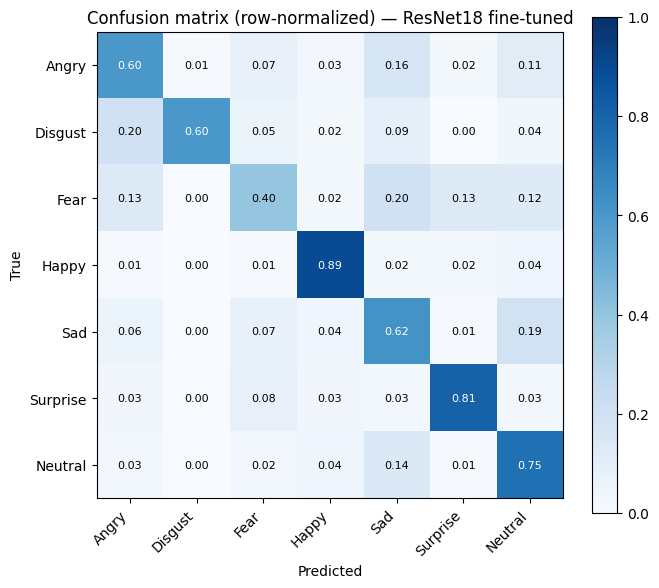

In [11]:
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(7)); ax.set_yticks(range(7))
ax.set_xticklabels(emotion_names, rotation=45, ha='right')
ax.set_yticklabels(emotion_names)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion matrix (row-normalized) — ResNet18 fine-tuned')
for i in range(7):
    for j in range(7):
        ax.text(j, i, f'{cm_norm[i,j]:.2f}', ha='center', va='center',
                color='white' if cm_norm[i,j] > 0.5 else 'black', fontsize=8)
plt.colorbar(im); plt.tight_layout(); plt.show()